nothig here yet

In [11]:
import torch

t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0,-4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = [x*0.1 for x in t_c]
t_u = [x*0.1 for x in t_u]
t_c = torch.tensor(t_c).unsqueeze(1)
t_u = torch.tensor(t_u).unsqueeze(1)

t_u.shape

torch.Size([11, 1])

making a model using torch nn

In [ ]:
"""
this this linear model so it will only have one linear layer
followed by an optimization function
which will take care of the calculating the derivative/gradient
and updating the paremeters

the optimizer we are using is stochastic gradient decent
"""

import torch.nn as nn
import torch.optim as optim

linear_model = nn.Linear(1,1)
optimizer = optim.SGD(
    lr=1e-2,
    params=linear_model.parameters(),
)

list(linear_model.parameters())

[Parameter containing:
 tensor([[-0.5713]], requires_grad=True),
 Parameter containing:
 tensor([0.7955], requires_grad=True)]

creating a training loop with nn linear model

In [13]:
def training_loop(
        n_epochs,
        optimizer,
        model,
        loss_fn,
        t_c,
        t_u
    ):

    for epoch in range(1,n_epochs+1):
        t_p = model(t_u)
        loss = loss_fn(t_p, t_c)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss.item():.4f},")



In [14]:
training_loop(
    n_epochs=3000,
    model=linear_model,
    optimizer=optimizer,
    loss_fn= nn.MSELoss(),
    t_u=t_u,
    t_c=t_c
)
print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 13.5201,
Epoch 1000, Training loss 0.0497,
Epoch 2000, Training loss 0.0300,
Epoch 3000, Training loss 0.0293,

Parameter containing:
tensor([[0.5339]], requires_grad=True)
Parameter containing:
tensor([-1.7144], requires_grad=True)


now with a sequential model

In [17]:
seq_mod = nn.Sequential(
    nn.Linear(1,13),
    nn.Tanh(),
    nn.Linear(31,1)
)

print(seq_mod)
print("=======================================")
[param.shape for param in seq_mod.parameters()]

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=31, out_features=1, bias=True)
)


[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 31]), torch.Size([1])]

In [18]:
# you can you ordered dict to give name to each layer

from collections import OrderedDict
seq_mod = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8, 1))
    ]))
seq_mod

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [20]:
optimizer = optim.SGD(seq_mod.parameters(), lr=1e-3)

training_loop(
    n_epochs = 5000,
    optimizer = optimizer,
    model = seq_mod,
    loss_fn = nn.MSELoss(),
    t_u = t_u,
    t_c = t_c)

print('output', seq_mod(t_u))
print('answer', t_c)
print('hidden', seq_mod.hidden_linear.weight.grad)

Epoch 1, Training loss 0.0913,
Epoch 1000, Training loss 0.0614,
Epoch 2000, Training loss 0.0509,
Epoch 3000, Training loss 0.0451,
Epoch 4000, Training loss 0.0414,
Epoch 5000, Training loss 0.0387,
output tensor([[ 0.1817],
        [ 1.2918],
        [ 1.4136],
        [ 2.4855],
        [ 1.3131],
        [ 0.9107],
        [ 0.0841],
        [-0.5467],
        [ 0.8831],
        [ 1.5280],
        [ 1.9216]], grad_fn=<AddmmBackward0>)
answer tensor([[ 0.0500],
        [ 1.4000],
        [ 1.5000],
        [ 2.8000],
        [ 1.1000],
        [ 0.8000],
        [ 0.3000],
        [-0.4000],
        [ 0.6000],
        [ 1.3000],
        [ 2.1000]])
hidden tensor([[ 0.0006],
        [ 0.0012],
        [ 0.0005],
        [ 0.0036],
        [-0.0038],
        [ 0.0006],
        [ 0.0020],
        [ 0.0045]])


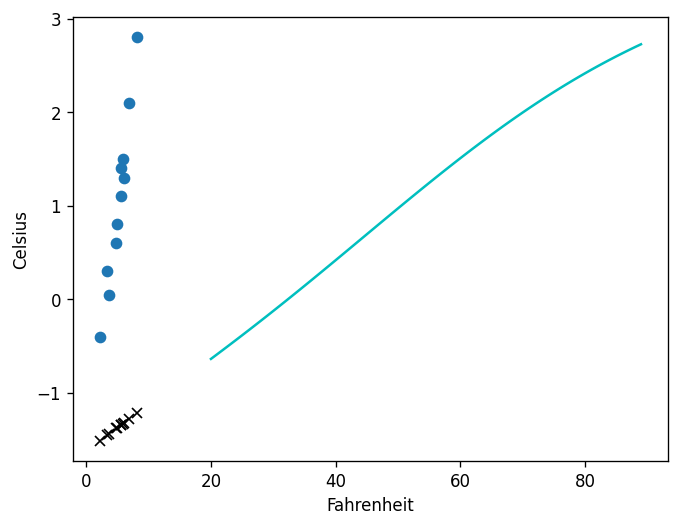

In [ ]:
# had to graph it in the end to look cool i guess
# the graph isnt what i was hoping, will see later

from matplotlib import pyplot as plt
t_range = torch.arange(20., 90.).unsqueeze(1)
fig = plt.figure(dpi=120)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_mod(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_mod(0.1 * t_u).detach().numpy(), 'kx')